# End-to-End Machine Learning Exercise


**Prepared by:** **Ali H. El-Kassas**  
*Senior Data Scientist | Machine Learning Instructor*

This notebook is intended to help students practice the complete machine learning workflow, including exploratory data analysis, data preprocessing, feature engineering, model training, hyperparameter tuning, and error analysis.

Complete all `TODO` sections.

### Objectives

Build a machine learning pipeline that predicts the Manufacturer Suggested Retail Price (MSRP) of a car.

- Frame the problem
- Select a Performance Measure
- Quick look on the data
- Train/Validation/Test split
- EDA
- Preprocessing
- Pipelines
- Modeling
- Fine-Tuning
- Error Analysis
- Final Evaluation
- Deploy the model

In [70]:
# TODO Import all the lib that you need here
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeRegressor

In [71]:
# TODO: Load the dataset
df = pd.read_csv("data.csv")

## Initial Inspection
Inspect shape, dtypes, missing values, duplicates and descriptive statistics.

In [72]:
# TODO
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5

In [73]:
df['Transmission Type'].value_counts()

Transmission Type
AUTOMATIC           8266
MANUAL              2935
AUTOMATED_MANUAL     626
DIRECT_DRIVE          68
UNKNOWN               19
Name: count, dtype: int64

In [74]:
# TODO
df.shape

(11914, 16)

In [75]:
# TODO
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [76]:
# TODO
df.describe()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


In [77]:
# TODO
df.isnull().sum()

Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64

## Train / Validation / Test Split
Split data into Train, Validation and Test sets.

In [78]:
# TODO
x = df.drop(columns = 'MSRP')
y = df['MSRP']


x_train_val, x_test, y_train_val, y_test = train_test_split(x, y, test_size = .2, random_state = 500)
x_train, x_val, y_train, y_val = train_test_split(x_train_val, y_train_val, test_size = .2, random_state = 500)

## Exploratory Data Analysis

### Numerical Features



- Histograms
- KDE plots
- Boxplots
- Distribution of MSRP
- Identify skewed features

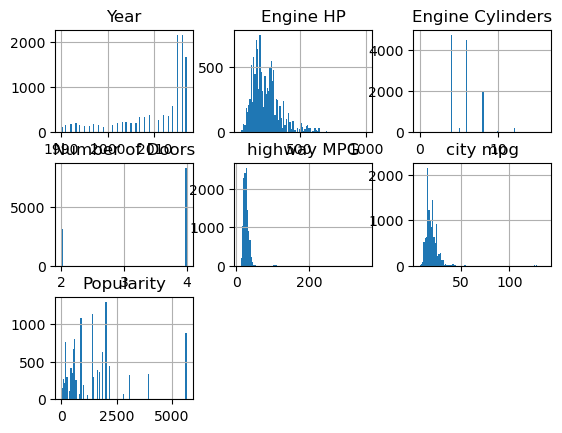

In [79]:
# TODO

import matplotlib.pyplot as plt

x.hist(bins = 100);

## Outlier Detection


- Identify outliers using boxplots
- Decide whether to remove them and explain why?

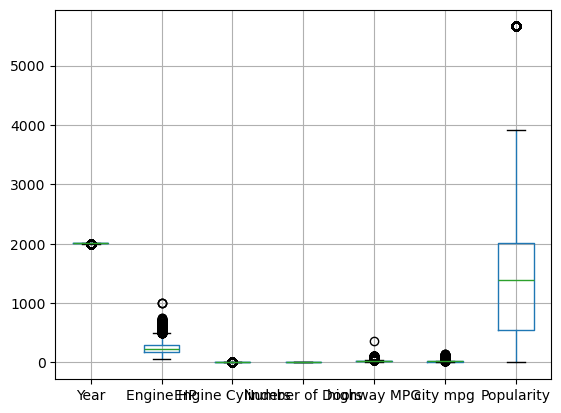

In [80]:
# TODO

x.boxplot();

- We have the outlier in Engine HP, highway MGP, & City mpg.
- We can use the MinMaxScaler to make the number near & semilar.
- we can remove the outlier.

### Categorical Features



- Countplots
- Number of unique values

In [81]:
# TODO

categorical_cols = x_train.select_dtypes(include=['object']).columns

unique_values = x_train[categorical_cols].nunique().sort_values(ascending=False)
unique_values

Model                880
Market Category       67
Make                  48
Vehicle Style         16
Engine Fuel Type       9
Transmission Type      5
Driven_Wheels          4
Vehicle Size           3
dtype: int64

<Axes: xlabel='count', ylabel='Make'>

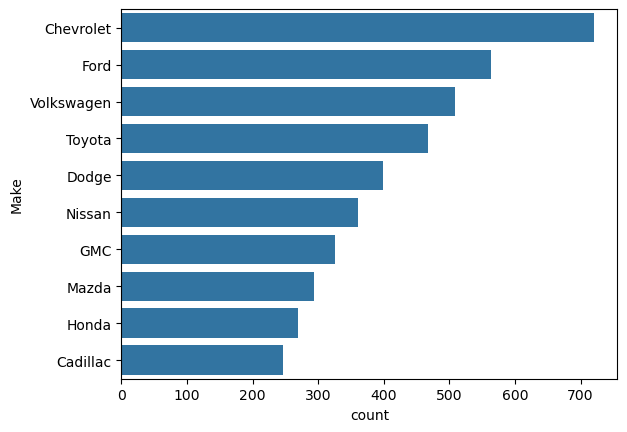

In [82]:
import seaborn as sns

cat_cols = x_train.select_dtypes(include = ['object']).columns
sns.countplot(data = x_train, y = cat_cols[0], order = x_train[cat_cols[0]].value_counts().index[:10])


### Relationship with Target

Tasks

- Scatterplots
- Correlation heatmap
- Pairplots (selected columns)


In [83]:
import numpy as np

In [84]:
num_cols = x_train.select_dtypes(include = [np.number]).columns.tolist()

Text(0.5, 1.0, 'Correlation Heatmap')

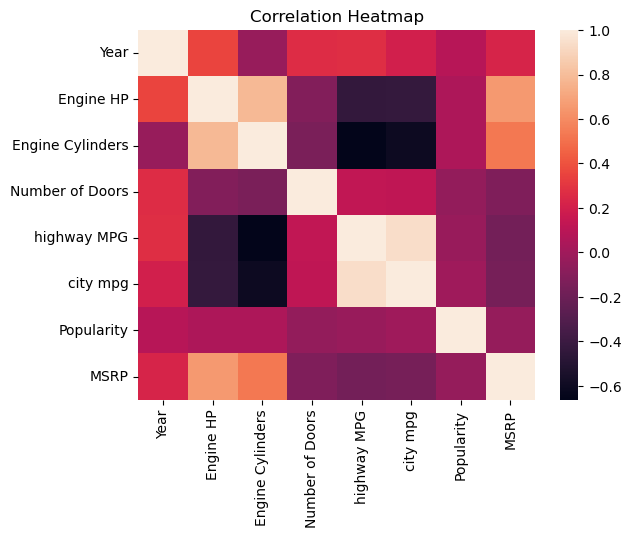

In [85]:
# TODO
train_data = x_train.copy()
train_data['MSRP'] = y_train
sns.heatmap(train_data[num_cols + ['MSRP']].corr())
plt.title("Correlation Heatmap")


Questions:

- Which features seem most correlated with price?

In [86]:
# TODO - No Code
# Engine HP is the most corr with MSRP

## Feature Engineering
Create at least two new features that may improve performance.

Possible ideas

- Engine HP per Cylinder

- Power-to-weight proxy


**You should do the same step for the `val` and `test`**

In [87]:
# TODO
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='object')

In [88]:
df['hp_per_cylinder'] = df['Engine HP'] / df['Engine Cylinders']
df['power_to_weight'] = df['Engine HP'] / df['highway MPG']
df

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP,hp_per_cylinder,power_to_weight
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135,55.833333,12.884615
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650,50.000000,10.714286
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350,50.000000,10.714286
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450,38.333333,8.214286
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500,38.333333,8.214286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120,50.000000,13.043478
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670,50.000000,13.043478
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620,50.000000,13.043478
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920,50.000000,13.043478


## Preprocessing
Identify numerical and categorical columns and build a ColumnTransformer.

In [89]:
# TODO
num_cols = ['Year', 'Engine HP', 'Engine Cylinders', 'Number of Doors', 'highway MPG', 'city mpg', 'Popularity']
cat_cols = ['Make', 'Model', 'Engine Fuel Type', 'Transmission Type', 'Driven_Wheels', 'Market Category', 'Vehicle Size', 'Vehicle Style']

## Pipeline
Create a preprocessing + model pipeline.

In [90]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

In [91]:
# TODO
num_pipe = make_pipeline(
    SimpleImputer(strategy = 'median'),
    MinMaxScaler())


In [92]:
cat_pipe = make_pipeline(
    SimpleImputer(strategy = 'most_frequent'),
    OneHotEncoder(handle_unknown = 'ignore'))

In [93]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', num_pipe, num_cols),
        ('cat', cat_pipe, cat_cols)])

## Baseline Model
Train a Linear Regression model and evaluate using MAE, RMSE and MSE.

In [94]:
from sklearn.linear_model import LinearRegression

In [95]:
baseline_pipe = make_pipeline(preprocessor, LinearRegression())
baseline_pipe.fit(x_train, y_train)

,steps,"[('columntransformer', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [96]:
# TODO
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

y_pred_val = baseline_pipe.predict(x_val)

mae = mean_absolute_error(y_val, y_pred_val)
mse = mean_squared_error(y_val, y_pred_val)
rmse = np.sqrt(mse)

print(mae)
print(mse)
print(rmse)


4690.809220605224
897723578.7767135
29962.03562471538


How well does Linear Regression perform?

In [97]:
# TODO 
# The mean squared error is considered very large, and It is not suitable for linear relationships

## Model Comparison
Compare at least two regression models.

In [98]:
# TODO
cars_pipe = make_pipeline(preprocessor, DecisionTreeRegressor(random_state = 42))

cars_pipe.fit(x_train, y_train)

cars_mae = mean_absolute_error(y_val, cars_pipe.predict(x_val))

print(cars_mae)

4322.153778893134


In [99]:
from sklearn.linear_model import LinearRegression

full_pipe = make_pipeline(preprocessor, DecisionTreeRegressor())
full_pipe.fit(x_train, y_train)

,steps,"[('columntransformer', ...), ('decisiontreeregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Hyperparameter Tuning
Tune your best model using GridSearchCV.

In [100]:
# TODO
from sklearn.model_selection import GridSearchCV

grid = {'decisiontreeregressor__max_depth': [5, 6, 15, 10],
        'decisiontreeregressor__max_leaf_nodes': [2, 5, 10] 
       }

model = GridSearchCV(full_pipe, grid)

model.fit(x_train, y_train)

,estimator,Pipeline(step...Regressor())])
,param_grid,"{'decisiontreeregressor__max_depth': [5, 6, ...], 'decisiontreeregressor__max_leaf_nodes': [2, 5, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


Repeat using RandomizedSearchCV.

In [101]:
# TODO
from sklearn.model_selection import RandomizedSearchCV

grid = {'decisiontreeregressor__max_depth': [5, 6, 15, 10],
        'decisiontreeregressor__max_leaf_nodes': [2, 5, 10] 
       }

model = RandomizedSearchCV(full_pipe, grid)

model.fit(x_train, y_train)

,estimator,Pipeline(step...Regressor())])
,param_distributions,"{'decisiontreeregressor__max_depth': [5, 6, ...], 'decisiontreeregressor__max_leaf_nodes': [2, 5, ...]}"
,n_iter,10
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


Which method was faster? Did both produce similar results?

In [102]:
# TODO
# It's the same result, & the RandomizedSearchCV is the faster

## Error Analysis (Bonus)

Predict on validation set

In [103]:
# TODO


Compute residuals

`Actual - Predicted`

In [104]:
# TODO

Plot residuals, Predicted vs Actual, investigate largest errors.

- Where does the model fail?

In [105]:
#TODO-NO CODE

Which cars have the highest prediction errors?

In [106]:
#TODO-NO CODE

Are expensive cars harder to predict?

In [107]:
#TODO-NO CODE

## Final Test Evaluation
Evaluate **only once** on the held-out test set.

In [108]:
# TODO
y_pred = model.predict(x_test)
mean_absolute_error(y_test, y_pred)

9948.787594120611

## Deployment (Bonus)
Deploy your model using streamlit

In [109]:
full_pipe

,steps,"[('columntransformer', ...), ('decisiontreeregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [110]:
import joblib 

joblib.dump(full_pipe, "model.pkl")

['model.pkl']

## Reflection
Summarize findings.

- Which preprocessing steps were essential?
- Which model performed best?
- Why?
- Did hyperparameter tuning improve performance?
- Which features contributed most?
- What additional data would improve predictions?
- If this model were deployed in production, what challenges might arise?

In [111]:
# TODO
#Data Cleaning: We handled missing values, converted text to numerical data, and organized the dataset.
#Best Model: The final decision tree outperformed the linear model, proving more effective with complex data.
#Optimization: Adjustments were made, though they did not significantly impact performance.
#Key Price Drivers: Engine power, model year, and brand.

## Bonus Challenges - 1
- Remove outliers and compare. Did performance improve?
  


In [112]:
#TODO

## Bonus Challenges - 2

Perform feature selection